In [220]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

In [221]:
RANDOM_STATE = 42

In [222]:
# 1) Load dataset
data = fetch_openml(name="credit-g", version=1, as_frame=True)
df = data.frame.copy()

In [223]:
target_col = "class"
X_df = df.drop(columns=[target_col])
y = df[target_col]

In [224]:
numeric_features = X_df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_df.select_dtypes(exclude=["int64", "float64"]).columns.tolist()
print(f"Numeric features ({len(numeric_features)}): {numeric_features}")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")

Numeric features (7): ['duration', 'credit_amount', 'installment_commitment', 'residence_since', 'age', 'existing_credits', 'num_dependents']
Categorical features (13): ['checking_status', 'credit_history', 'purpose', 'savings_status', 'employment', 'personal_status', 'other_parties', 'property_magnitude', 'other_payment_plans', 'housing', 'job', 'own_telephone', 'foreign_worker']


In [225]:
# 3) Preprocess
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=0.02, sparse_output=False), categorical_features),
    ],
    remainder="drop"
)

In [226]:
pipe = Pipeline([
    ("preprocess", preprocess),
    ("pca", PCA(n_components=0.8, random_state=RANDOM_STATE))
])

In [227]:
X_reduced = pipe.fit_transform(X_df)
print("Original transformed dim (after OHE):", preprocess.fit_transform(X_df).shape[1])
print("Reduced dim (after PCA 0.8):", X_reduced.shape[1])

Original transformed dim (after OHE): 59
Reduced dim (after PCA 0.8): 18


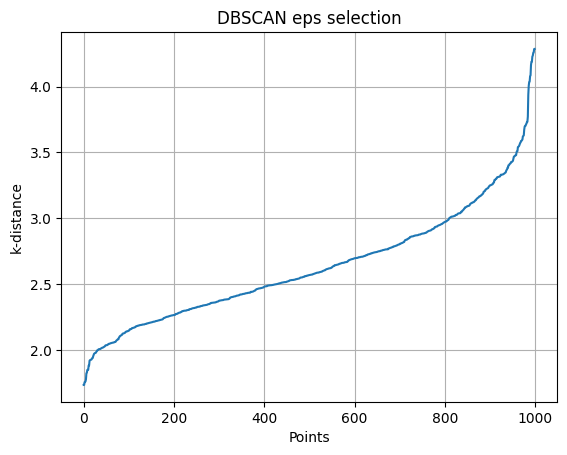

In [228]:
#DBSCAN eps selector
k = 10
nbrs = NearestNeighbors(n_neighbors=k).fit(X_reduced)
distances, _ = nbrs.kneighbors(X_reduced)

distances = np.sort(distances[:, k-1])

plt.plot(distances)
plt.ylabel("k-distance")
plt.xlabel("Points")
plt.title("DBSCAN eps selection")
plt.grid(True)
plt.show()

In [229]:
db = DBSCAN(
    eps=3.5,        # will tune
    min_samples=36  # rule of thumb: 2 × PCA dims
)

db_labels = db.fit_predict(X_reduced)

In [230]:
#Identify outliers
outlier_mask = db_labels == -1
n_outliers = outlier_mask.sum()

print(f"Outliers detected: {n_outliers} ({n_outliers/len(X_reduced)*100:.2f}%)")

Outliers detected: 22 (2.20%)


In [231]:
X_clean = X_reduced[~outlier_mask]

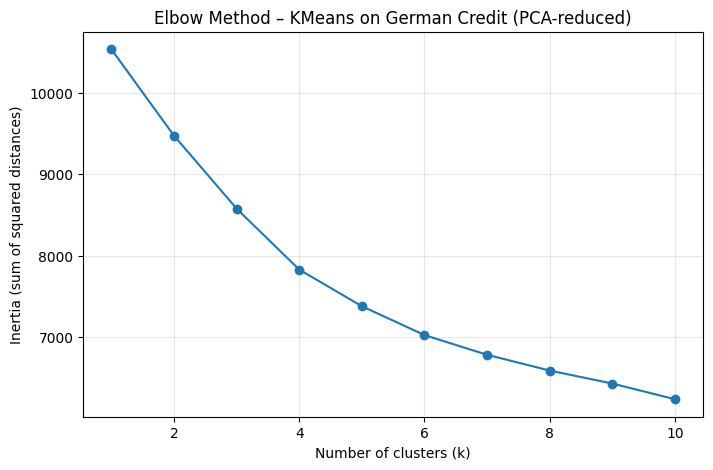

In [232]:
#Elbow method
k_values = list(range(1, 11))
inertias = []
for k in k_values:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_clean)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker='o')
plt.title("Elbow Method – KMeans on German Credit (PCA-reduced)")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (sum of squared distances)")
plt.grid(True, alpha=0.3)
plt.show()

In [233]:
k_opt = 4

In [234]:
km_final = KMeans(n_clusters=k_opt, random_state=RANDOM_STATE, n_init=10)
km_labels = km_final.fit_predict(X_clean)

Explained variance ratio (vis PC1, PC2): [0.149 0.143]


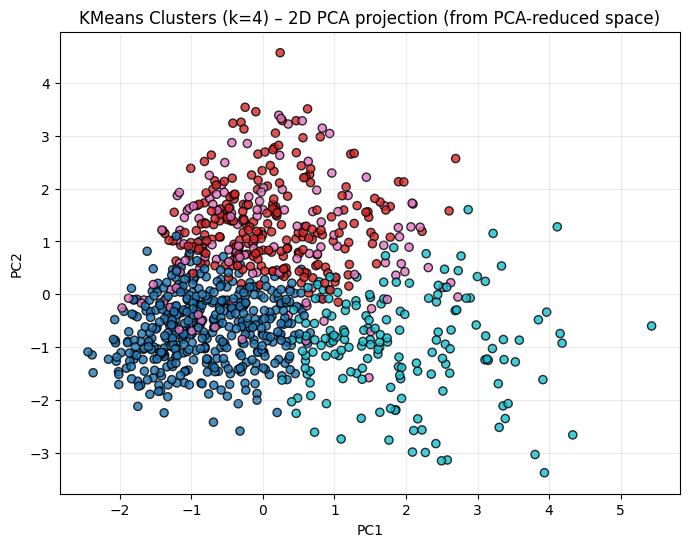

In [235]:
# 2D visualization
# PCA to 2D from X_reduced for plotting
pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
X_vis2 = pca2.fit_transform(X_clean)
print("Explained variance ratio (vis PC1, PC2):", np.round(pca2.explained_variance_ratio_, 3))

plt.figure(figsize=(8, 6))
plt.scatter(X_vis2[:, 0], X_vis2[:, 1], c=km_labels, cmap="tab10", s=35, edgecolor="k", alpha=0.8)
plt.title(f"KMeans Clusters (k={k_opt}) – 2D PCA projection (from PCA-reduced space)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True, alpha=0.25)
plt.show()

In [236]:
# 3D visualization
# PCA to 3D from X_reduced for plotting

pca3 = PCA(n_components=3, random_state=RANDOM_STATE)
X_vis3 = pca3.fit_transform(X_clean)
print("Explained variance ratio (vis PC1, PC2, PC3):", np.round(pca3.explained_variance_ratio_, 3))

df_plot = pd.DataFrame({
    "PC1": X_vis3[:, 0],
    "PC2": X_vis3[:, 1],
    "PC3": X_vis3[:, 2],
    "cluster": km_labels.astype(str)
})

fig = px.scatter_3d(
    df_plot, x="PC1", y="PC2", z="PC3",
    color="cluster",
    opacity=0.8,
    title=f"KMeans Clusters (k={k_opt}) – 3D PCA projection (from PCA-reduced space)"
)
fig.show()

Explained variance ratio (vis PC1, PC2, PC3): [0.149 0.143 0.105]


In [237]:
sil_km = silhouette_score(X_clean, km_labels)
print(f"\nSilhouette score (KMeans, k={k_opt}) on PCA-reduced and DBSCAN cleaned data: {sil_km:.3f}")


Silhouette score (KMeans, k=4) on PCA-reduced and DBSCAN cleaned data: 0.128


In [238]:
# 8) Cluster profiling
# Numeric: mean per cluster (original scale)
X_df = X_df[~outlier_mask]
num_df = X_df[numeric_features].copy()
num_df["Cluster"] = km_labels
num_profile = num_df.groupby("Cluster").mean().round(2)
print("\nNumeric feature means by cluster (KMeans):")
print(num_profile)

# Categorical: proportions per cluster (top categories displayed)
cat_profile = {}
if len(categorical_features) > 0:
    cat_df = X_df[categorical_features].copy()
    cat_df["Cluster"] = km_labels
    for col in categorical_features:
        # normalized value counts per cluster
        vc = (
            cat_df.groupby("Cluster")[col]
            .value_counts(normalize=True)
            .rename("proportion")
            .reset_index()
        )
        # Keep top categories per cluster for readability
        cat_profile[col] = vc.sort_values(["Cluster", "proportion"], ascending=[True, False])

    print("\nCategorical proportions by cluster (KMeans) – top categories:")
    for col, table in cat_profile.items():
        print(f"\n{col}:")
        # Show only top 3 categories per cluster
        for cl in sorted(table["Cluster"].unique()):
            top3 = table[table["Cluster"] == cl].head(3)
            print(top3.to_string(index=False))


Numeric feature means by cluster (KMeans):
         duration  credit_amount  installment_commitment  residence_since  \
Cluster                                                                     
0           16.58        2100.09                    2.97             2.42   
1           17.07        2257.23                    3.30             3.67   
2           18.40        2862.49                    2.79             2.92   
3           37.57        7177.69                    2.75             2.66   

           age  existing_credits  num_dependents  
Cluster                                           
0        28.76              1.24            1.00  
1        47.60              1.58            1.00  
2        37.78              1.50            2.00  
3        33.37              1.45            1.02  

Categorical proportions by cluster (KMeans) – top categories:

checking_status:
 Cluster checking_status  proportion
       0     no checking    0.363844
       0              <0    0.29